# §4.12 ETTh1 Ablation — 벽돌빼기 실험

**실험 목적**: Nomadic Full (ETTh1 24-step) 대비 각 구성요소 제거 시 성능 변화 측정.
어떤 컴포넌트가 MSE 개선과 ΔH에 각각 기여하는지 분리.

**베이스라인**: §4.11 ETTh1 24-step 결과
- Standard MoE: MSE=0.147 ± 0.016, ΔH=+0.001
- Nomadic Full:  MSE=0.126 ± 0.011, ΔH=−0.009

**Ablation variants** (Nomadic Full에서 하나씩 제거):

| Variant | 제거 대상 | 플래그 |
|---|---|---|
| No PolicyNet | PolicyNet 완전 제거 (gate routing만 사용) | `use_policy=False` |
| No Δx_err | GateNet 입력에서 delta_err 채널 제거 | `use_delta_err=False` |
| No L_cons | consistency loss (λ_cons) 제거 | `lambda_cons=0.0` |
| No L_dwell | dwell-time regularizer 제거 | `use_dwell=False` |
| Nomadic Full | 모든 컴포넌트 포함 (reference) | all enabled |

**예측 horizon**: 24-step-ahead (OT_{t+24})
**Seeds**: 42, 123, 456 | **Epochs**: 220

---
**자체 실험 가이드** (ema_decay / horizon 변경 시):
- horizon 변경: STEP 4의 `HORIZON = 24` 수정
- ema_decay 변경: STEP 3의 `Config.ema_decay` 수정
- 특정 variant만 재실험: STEP 9의 `RUN_VARIANTS` 리스트 편집

In [30]:
# ============================================================
# STEP 0: 환경 확인
# ============================================================
import torch
print(f'PyTorch: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

PyTorch: 2.10.0+cu128
CUDA available: True
GPU: NVIDIA L4
VRAM: 23.7 GB


In [31]:
# ============================================================
# STEP 1: Google Drive 마운트 & 경로 설정
# ============================================================
# --- 방법 A: Google Drive 마운트 ---
# from google.colab import drive
# drive.mount('/content/drive')
# CSV_PATH = '/content/drive/MyDrive/ETTh1.csv'

# --- 방법 B: 직접 업로드 ---
# from google.colab import files
# uploaded = files.upload()
# CSV_PATH = 'ETTh1.csv'

CSV_PATH = 'ETTh1.csv'  # 실제 경로로 수정
print(f'CSV_PATH: {CSV_PATH}')

CSV_PATH: ETTh1.csv


In [32]:
# ============================================================
# STEP 2: Imports
# ============================================================
import os, random, math, time
from dataclasses import dataclass, field
from typing import Dict, List, Optional

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams['figure.dpi'] = 120

def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {DEVICE}')

Using device: cuda


In [33]:
# ============================================================
# STEP 3: Config
# ============================================================
@dataclass
class Config:
    seed: int = 42
    device: str = DEVICE

    # data
    input_dim: int = 7
    output_dim: int = 1
    roll_window: int = 24 * 7

    # model
    hidden_dim: int = 64
    num_experts: int = 3
    gate_hidden_dim: int = 64
    temperature: float = 0.60

    # training
    epochs: int = 220
    lr: float = 2e-3
    weight_decay: float = 1e-5
    batch_size: int = 64
    train_ratio: float = 0.70
    val_ratio: float = 0.15

    # ── delta signal
    # ema_decay 변경 실험: 0.50 / 0.65 / 0.80(default) / 0.90 / 0.95
    ema_decay: float = 0.80
    err_baseline_momentum: float = 0.85
    w_env: float = 1.0
    w_err: float = 2.0

    # ── ablation flags ──────────────────────────────────────
    use_policy: bool = False        # False → No PolicyNet
    use_delta_err: bool = True     # False → No Δx_err (gate input에서 제거)
    use_dwell: bool = True         # False → No L_dwell
    # lambda_cons=0.0 → No L_cons (아래에서 직접 제어)
    # ────────────────────────────────────────────────────────

    # loss weights
    alpha_dogma: float = 0.04
    beta_nomad: float = 0.05
    beta_phi: float = 0.02
    gamma_diversity: float = 0.08
    lambda_sep: float = 0.08
    lambda_cons: float = 0.00     # 0.0 → No L_cons
    lambda_load: float = 0.03
    tau_k_min: int = 3
    tau_k_penalty: float = 0.05

    # dynamic tau
    use_dynamic_tau: bool = True
    tau_min: float = 2.0
    tau_max: float = 8.0
    tau_var_scale: float = 6.0
    tau_var_window: int = 8

    # phi
    phi_scale_env: float = 1.0
    phi_scale_err: float = 1.5
    phi_scale_explain: float = 1.5
    phi_scale_gap: float = 0.8
    temp_stable: float = 0.35
    temp_transition: float = 0.90
    use_hard_switch: bool = True
    phi_hard_threshold: float = 0.30

    # policy
    policy_hidden_dim: int = 64
    policy_mix_weight: float = 0.25
    policy_weight_stay: float = 0.20
    policy_weight_target: float = 0.20
    policy_weight_mode: float = 0.10

    save_dir: str = 'outputs_etth1_ablation'


# ── Ablation variant 정의 ──────────────────────────────────
# (label, Config kwargs override)
ABLATION_VARIANTS = [
    ('Nomadic_Full',   {}),
]

# 특정 variant만 실험하려면 아래 리스트 편집
# 예: RUN_VARIANTS = ['No_PolicyNet', 'No_DeltaErr']
RUN_VARIANTS = [v[0] for v in ABLATION_VARIANTS]  # 전체 실행

SEEDS = [42, 123, 456]
HORIZON = 24   # 1 또는 24 — 직접 변경 가능

os.makedirs(Config().save_dir, exist_ok=True)
print(f'Variants to run: {RUN_VARIANTS}')
print(f'Horizon: {HORIZON}-step ahead | ema_decay: {Config().ema_decay}')

Variants to run: ['Nomadic_Full']
Horizon: 24-step ahead | ema_decay: 0.8


In [34]:
# ============================================================
# STEP 4: Data Preprocessing
# ============================================================
def load_etth1(csv_path: str, cfg: Config, horizon: int = 24):
    df = pd.read_csv(csv_path)
    df['date'] = pd.to_datetime(df['date'])
    df = df.sort_values('date').reset_index(drop=True)

    feature_cols = ['HUFL', 'HULL', 'MUFL', 'MULL', 'LUFL', 'LULL', 'OT']

    df['roll_std'] = df['OT'].rolling(cfg.roll_window).std()
    df = df.dropna(subset=['roll_std']).reset_index(drop=True)

    # horizon-step ahead target
    df['target'] = df['OT'].shift(-horizon)
    df = df.dropna(subset=['target']).reset_index(drop=True)

    n = len(df)
    n_train = int(n * cfg.train_ratio)
    p33 = df['roll_std'].iloc[:n_train].quantile(0.33)
    p67 = df['roll_std'].iloc[:n_train].quantile(0.67)
    df['regime'] = 0
    df.loc[df['roll_std'] >= p33, 'regime'] = 1
    df.loc[df['roll_std'] >= p67, 'regime'] = 2

    X_raw = df[feature_cols].values.astype(np.float32)
    Y_raw = df['target'].values.astype(np.float32).reshape(-1, 1)
    R_raw = df['regime'].values.astype(np.int64)

    x_mean = X_raw[:n_train].mean(0); x_std = X_raw[:n_train].std(0) + 1e-8
    y_mean = Y_raw[:n_train].mean();  y_std = Y_raw[:n_train].std()  + 1e-8
    X_norm = (X_raw - x_mean) / x_std
    Y_norm = (Y_raw - y_mean) / y_std

    print(f'ETTh1 horizon={horizon}: {n} rows | '
          f'train={n_train} | '
          f'Regime dist: { {i: int((R_raw==i).sum()) for i in range(3)} }')
    return X_norm, Y_norm, R_raw


def make_splits(X, Y, R, cfg: Config):
    n = len(X)
    n_train = int(n * cfg.train_ratio)
    n_val   = int(n * cfg.val_ratio)

    def t(arr, dtype=torch.float32):
        return torch.tensor(arr, dtype=dtype).to(cfg.device)

    return {
        'train': {'X': t(X[:n_train]),          'Y': t(Y[:n_train]),
                  'R': t(R[:n_train], torch.long)},
        'test':  {'X': t(X[n_train+n_val:]),     'Y': t(Y[n_train+n_val:]),
                  'R': t(R[n_train+n_val:], torch.long)},
    }


def make_phase_tags(R_tensor, batch_size, window=2):
    R = R_tensor.cpu().numpy()
    n = len(R)
    names = {0: 'LowVol', 1: 'MidVol', 2: 'HighVol'}
    tags_sample = [f'stable_{names[R[i]]}' for i in range(n)]
    for i in range(1, n):
        if R[i] != R[i-1]:
            for j in range(max(0, i-window), min(n, i+window+1)):
                tags_sample[j] = f'transition_{names[R[i-1]]}_to_{names[R[i]]}'
    # 배치 단위 태그 (각 배치 첫 샘플)
    return [tags_sample[i] for i in range(0, n, batch_size)]


# 데이터 로드 (seed 무관, 한 번만)
_cfg0 = Config()
X_all, Y_all, R_all = load_etth1(CSV_PATH, _cfg0, horizon=HORIZON)
splits_global = make_splits(X_all, Y_all, R_all, _cfg0)
phase_tags    = make_phase_tags(splits_global['test']['R'], _cfg0.batch_size)
print(f'Phase tags — stable: {sum(1 for t in phase_tags if t.startswith("stable_"))}, '
      f'transition: {sum(1 for t in phase_tags if t.startswith("transition_"))}')

ETTh1 horizon=24: 17229 rows | train=12060 | Regime dist: {0: 7938, 1: 4909, 2: 4382}
Phase tags — stable: 38, transition: 3


In [35]:
# ============================================================
# STEP 5: Model Definitions
# ============================================================
class Expert(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim), nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim), nn.Tanh(),
            nn.Linear(hidden_dim, output_dim),
        )
    def forward(self, x): return self.net(x)


class GateNet(nn.Module):
    """
    use_delta_err=True  → 입력: [x, delta_hybrid, delta_err]  (input_dim + 2)
    use_delta_err=False → 입력: [x, delta_hybrid]             (input_dim + 1)
    """
    def __init__(self, input_dim, gate_hidden_dim, num_experts, use_delta_err=True):
        super().__init__()
        self.use_delta_err = use_delta_err
        in_dim = input_dim + (2 if use_delta_err else 1)
        self.net = nn.Sequential(
            nn.Linear(in_dim, gate_hidden_dim), nn.ReLU(),
            nn.Linear(gate_hidden_dim, gate_hidden_dim), nn.ReLU(),
            nn.Linear(gate_hidden_dim, num_experts),
        )
    def forward(self, x, delta_hybrid, delta_err=None, temperature=1.0):
        if self.use_delta_err:
            gate_input = torch.cat([x, delta_hybrid, delta_err], dim=-1)
        else:
            gate_input = torch.cat([x, delta_hybrid], dim=-1)
        return F.softmax(self.net(gate_input) / temperature, dim=-1), self.net(gate_input)


class PolicyNet(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_experts):
        super().__init__()
        self.shared = nn.Sequential(
            nn.Linear(input_dim + 5, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
        )
        self.stay_switch_head = nn.Linear(hidden_dim, 2)
        self.target_head      = nn.Linear(hidden_dim, num_experts)
        self.mode_head        = nn.Linear(hidden_dim, 2)
    def forward(self, x):
        h = self.shared(x)
        return (F.softmax(self.stay_switch_head(h), dim=-1),
                F.softmax(self.target_head(h),      dim=-1),
                F.softmax(self.mode_head(h),        dim=-1))


class NomadicMoE(nn.Module):
    def __init__(self, cfg: Config):
        super().__init__()
        self.cfg         = cfg
        self.num_experts = cfg.num_experts
        self.experts = nn.ModuleList([
            Expert(cfg.input_dim, cfg.hidden_dim, cfg.output_dim)
            for _ in range(cfg.num_experts)
        ])
        self.gate = GateNet(
            cfg.input_dim, cfg.gate_hidden_dim, cfg.num_experts,
            use_delta_err=cfg.use_delta_err
        )
        # PolicyNet: use_policy=False 이면 인스턴스는 만들지만 forward에서 무시
        self.policy = PolicyNet(cfg.input_dim, cfg.policy_hidden_dim, cfg.num_experts)

    def forward(self, x, delta_hybrid, delta_err, temperature=1.0):
        gate_probs, logits = self.gate(x, delta_hybrid, delta_err, temperature)
        expert_outputs = torch.stack([e(x) for e in self.experts], dim=1)
        y_hat = (gate_probs.unsqueeze(-1) * expert_outputs).sum(dim=1)
        return y_hat, gate_probs, logits, expert_outputs


def count_params(model):
    return sum(p.numel() for p in model.parameters())

# 파라미터 수 확인
for label, overrides in ABLATION_VARIANTS:
    from dataclasses import replace
    cfg_v = Config(**overrides)
    m = NomadicMoE(cfg_v)
    print(f'{label:20s}: {count_params(m):,} params')

Nomadic_Full        : 24,653 params


In [36]:
# ============================================================
# STEP 6: Signal Utilities
# ============================================================
class HybridDeltaTracker:
    def __init__(self, cfg: Config):
        self.cfg = cfg
        self.reset()

    def reset(self):
        self.prev_x_mean  = None
        self.ema_err      = 0.0
        self.baseline_err = 0.0
        self.var_window   = []

    def compute(self, xb, batch_mse):
        cfg = self.cfg
        x_mean = xb.mean(0)
        de = 0.0 if self.prev_x_mean is None else \
             float((x_mean - self.prev_x_mean).norm(2).item())
        self.prev_x_mean = x_mean.detach()

        mse_val = float(batch_mse.item()) if isinstance(batch_mse, torch.Tensor) else float(batch_mse)
        self.ema_err      = cfg.ema_decay * self.ema_err + (1 - cfg.ema_decay) * mse_val
        self.baseline_err = cfg.err_baseline_momentum * self.baseline_err + \
                            (1 - cfg.err_baseline_momentum) * self.ema_err
        derr  = float(max(0.0, self.ema_err - self.baseline_err))
        dh    = math.tanh(cfg.w_env * de + cfg.w_err * derr)

        self.var_window.append(de)
        if len(self.var_window) > cfg.tau_var_window:
            self.var_window.pop(0)
        sigma2  = float(np.var(self.var_window)) if len(self.var_window) > 1 else 0.0
        dyn_tau = cfg.tau_min + (cfg.tau_max - cfg.tau_min) * math.exp(-cfg.tau_var_scale * sigma2)

        dh_t = torch.full((xb.size(0), 1), dh, device=cfg.device)
        return dh_t, de, derr, dh, sigma2, dyn_tau


class DwellTimeRegularizer:
    def __init__(self, cfg: Config):
        self.cfg = cfg
        self.reset()

    def reset(self):
        self.current_expert = None
        self.dwell_count    = 0

    def compute(self, gate_probs, dyn_tau):
        if not self.cfg.use_dwell:
            return torch.tensor(0.0, device=gate_probs.device)
        top1 = int(gate_probs.argmax(-1).float().mean().round().item())
        if self.current_expert is None or top1 != self.current_expert:
            self.current_expert = top1; self.dwell_count = 1
        else:
            self.dwell_count += 1
        bonus = self.cfg.tau_k_penalty if self.dwell_count >= dyn_tau else 0.0
        return torch.tensor(bonus, dtype=torch.float32, device=gate_probs.device)


def gate_entropy(g):
    return -(g * (g + 1e-8).log()).sum(-1)

def compute_phi(de, derr, expl_err, gap, cfg):
    raw = (cfg.phi_scale_env     * de
           + cfg.phi_scale_err   * (derr if cfg.use_delta_err else 0.0)
           + cfg.phi_scale_explain * float(expl_err.item() if isinstance(expl_err, torch.Tensor) else expl_err)
           + cfg.phi_scale_gap   * float(gap.item() if isinstance(gap, torch.Tensor) else gap))
    return torch.tensor(math.tanh(raw), dtype=torch.float32, device=cfg.device)

def adaptive_temp(phi, cfg):
    p = float(phi.item()) if isinstance(phi, torch.Tensor) else float(phi)
    return cfg.temp_stable + (cfg.temp_transition - cfg.temp_stable) * p

def policy_input(xb, dh_t, derr_t, phi, sigma2, dyn_tau, cfg):
    phi_t = torch.full((xb.size(0), 1), float(phi.item() if isinstance(phi, torch.Tensor) else phi), device=cfg.device)
    sig_t = torch.full((xb.size(0), 1), sigma2,  device=cfg.device)
    tau_t = torch.full((xb.size(0), 1), dyn_tau, device=cfg.device)
    return torch.cat([xb, dh_t, derr_t, phi_t, sig_t, tau_t], dim=-1)

def explanation_signals(yb, y_hat, exp_out, gate_probs):
    with torch.no_grad():
        per_exp = torch.stack([F.mse_loss(exp_out[:, k, :], yb) for k in range(exp_out.size(1))])
        gap = F.relu(per_exp[gate_probs.argmax(-1).float().mean().long()] - per_exp.min())
    return F.mse_loss(y_hat, yb), gap

def diversity_loss(exp_out):
    K = exp_out.size(1)
    loss = sum(-F.cosine_similarity(exp_out[:, i, :], exp_out[:, j, :], dim=-1).mean()
               for i in range(K) for j in range(i+1, K))
    return loss / max(1, K*(K-1)//2)

def load_balance_loss(g):
    return g.mean(0).var()

def dogma_penalty(g):
    return (g.max(-1).values - 1.0/g.size(-1)).clamp(min=0).mean()

def nomad_bonus(g):
    return gate_entropy(g).mean()

def regime_gate_stats(g, rb):
    sep  = torch.tensor(0.0, device=g.device)
    cons = torch.tensor(0.0, device=g.device)
    ur = rb.unique()
    if len(ur) < 2: return sep, cons
    means = [g[rb==r].mean(0) for r in ur if (rb==r).sum() > 0]
    if len(means) >= 2:
        pairs = [(i, j) for i in range(len(means)) for j in range(i+1, len(means))]
        sep = -sum(F.cosine_similarity(means[i].unsqueeze(0), means[j].unsqueeze(0)).mean()
                   for i, j in pairs) / len(pairs)
    for r in ur:
        mask = rb==r
        if mask.sum() > 1: cons += g[mask].var(0).mean()
    return sep, cons

def policy_targets(yb, exp_out, phi, sigma2, dyn_tau, cfg):
    phi_val = float(phi.item() if isinstance(phi, torch.Tensor) else phi)
    per_exp = torch.stack([F.mse_loss(exp_out[:, k, :], yb) for k in range(exp_out.size(1))])
    return (1 if phi_val > cfg.phi_hard_threshold else 0,
            per_exp.argmin(),
            1 if (sigma2 < 0.01 and dyn_tau > cfg.tau_min + 1) else 0)

print('Signal utilities ready.')

Signal utilities ready.


In [37]:
# ============================================================
# STEP 7: Evaluation
# ============================================================
def evaluate(model, splits, tags, cfg):
    model.eval()
    X, Y, R = splits['test']['X'], splits['test']['Y'], splits['test']['R']
    tracker = HybridDeltaTracker(cfg); tracker.reset()
    all_y, all_g = [], []
    b_tags, b_ent, b_top1, b_reg = [], [], [], []

    with torch.no_grad():
        for i in range(0, len(X), cfg.batch_size):
            xb = X[i:i+cfg.batch_size]
            yb = Y[i:i+cfg.batch_size]
            rb = R[i:i+cfg.batch_size]

            z = torch.zeros((xb.size(0), 1), device=cfg.device)
            warm_mse = F.mse_loss(model(xb, z, z, cfg.temperature)[0], yb)
            dh_t, de, derr, dh, sigma2, dyn_tau = tracker.compute(xb, warm_mse)
            derr_t = torch.full((xb.size(0), 1), derr, device=cfg.device)

            _, pg, _, pe = model(xb, dh_t, derr_t, cfg.temperature)
            expl, gap = explanation_signals(yb, (pg.unsqueeze(-1)*pe).sum(1), pe, pg)
            phi  = compute_phi(de, derr, expl, gap, cfg)
            temp = adaptive_temp(phi, cfg)

            y_hat, g, _, exp_out = model(xb, dh_t, derr_t, temp)

            if cfg.use_policy:
                pi = policy_input(xb, dh_t, derr_t, phi, sigma2, dyn_tau, cfg)
                stay_sw, tgt_p, mode_p = model.policy(pi)
                mix = cfg.policy_mix_weight * float(stay_sw[:, 1].mean())
                tgt = torch.argmax(tgt_p.mean(0))
                toh = F.one_hot(tgt, cfg.num_experts).float().unsqueeze(0).expand(xb.size(0), -1)
                g   = (1-mix)*g + mix*((toh - g).detach() + g)
                if cfg.use_hard_switch and not (dh > cfg.phi_hard_threshold) \
                        and mode_p[:, 1].mean() > 0.5:
                    g = F.one_hot(g.argmax(-1), cfg.num_experts).float()
                y_hat = (g.unsqueeze(-1) * exp_out).sum(1)

            all_y.append(y_hat); all_g.append(g)
            bi = i // cfg.batch_size
            b_tags.append(tags[bi] if bi < len(tags) else 'stable_unknown')
            b_ent.append(gate_entropy(g).mean().item())
            b_top1.append(int(g.argmax(-1).float().mean().round().item()))
            b_reg.append(int(rb[0].item()))

    Y_hat = torch.cat(all_y); G = torch.cat(all_g)
    mse = F.mse_loss(Y_hat, Y).item()

    G_np = G.cpu().numpy(); R_np = R.cpu().numpy()
    usage = {r: G_np[R_np==r].mean(0) for r in range(3) if (R_np==r).sum() > 0}
    r2e   = {r: int(np.argmax(u)) for r, u in usage.items()}
    lats  = []
    for i in range(1, len(b_reg)):
        if b_reg[i] != b_reg[i-1]:
            tgt = r2e.get(b_reg[i], -1)
            if tgt < 0: continue
            for lag in range(1, min(10, len(b_reg)-i)):
                if b_top1[i+lag] == tgt: lats.append(lag); break

    sh = [e for t, e in zip(b_tags, b_ent) if t.startswith('stable_')]
    th = [e for t, e in zip(b_tags, b_ent) if t.startswith('transition_')]
    return mse, {
        'stable_h':  float(np.mean(sh))   if sh   else float('nan'),
        'trans_h':   float(np.mean(th))   if th   else float('nan'),
        'switch_lat': float(np.mean(lats)) if lats else float('nan'),
    }

print('Evaluation ready.')

Evaluation ready.


In [38]:
# ============================================================
# STEP 8: Training Loop (단일 함수, cfg 플래그로 분기)
# ============================================================
def train_one(cfg: Config, splits, tags):
    model = NomadicMoE(cfg).to(cfg.device)
    opt   = torch.optim.Adam(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
    X_tr, Y_tr, R_tr = splits['train']['X'], splits['train']['Y'], splits['train']['R']
    mse_log, dyn_log = [], []

    for epoch in range(cfg.epochs):
        model.train()
        tracker   = HybridDeltaTracker(cfg); tracker.reset()
        dwell_reg = DwellTimeRegularizer(cfg); dwell_reg.reset()

        for i in range(0, len(X_tr), cfg.batch_size):
            xb = X_tr[i:i+cfg.batch_size]
            yb = Y_tr[i:i+cfg.batch_size]
            rb = R_tr[i:i+cfg.batch_size]
            opt.zero_grad()

            # warm probe
            with torch.no_grad():
                z = torch.zeros((xb.size(0), 1), device=cfg.device)
                warm_mse = F.mse_loss(model(xb, z, z, cfg.temperature)[0], yb)
            dh_t, de, derr, dh, sigma2, dyn_tau = tracker.compute(xb, warm_mse)
            derr_t = torch.full((xb.size(0), 1), derr, device=cfg.device)

            with torch.no_grad():
                py, pg, _, pe = model(xb, dh_t, derr_t, cfg.temperature)
            expl, gap = explanation_signals(yb, py, pe, pg)
            phi  = compute_phi(de, derr, expl, gap, cfg)
            temp = adaptive_temp(phi, cfg)

            # forward
            y_hat, g, _, exp_out = model(xb, dh_t, derr_t, temp)
            final_g = g

            # PolicyNet branch
            if cfg.use_policy:
                pi = policy_input(xb, dh_t, derr_t, phi, sigma2, dyn_tau, cfg)
                stay_sw, tgt_p, mode_p = model.policy(pi)
                mix = cfg.policy_mix_weight * float(stay_sw[:, 1].mean())
                tgt = torch.argmax(tgt_p.mean(0))
                toh = F.one_hot(tgt, cfg.num_experts).float().unsqueeze(0).expand(xb.size(0), -1)
                final_g = (1-mix)*g + mix*((toh - g).detach() + g)
                if cfg.use_hard_switch and not (dh > cfg.phi_hard_threshold) \
                        and mode_p[:, 1].mean() > 0.5:
                    final_g = F.one_hot(final_g.argmax(-1), cfg.num_experts).float()
                y_hat = (final_g.unsqueeze(-1) * exp_out).sum(1)

            # losses
            _, gap_loss = explanation_signals(yb, y_hat, exp_out, final_g)
            sep_loss, cons_loss = regime_gate_stats(final_g, rb)
            dwell_bonus = dwell_reg.compute(final_g, dyn_tau)

            loss = (F.mse_loss(y_hat, yb)
                    + cfg.beta_phi        * (phi.detach() * gap_loss)
                    + cfg.alpha_dogma     * dogma_penalty(final_g)
                    - cfg.beta_nomad      * nomad_bonus(final_g)
                    + cfg.gamma_diversity * diversity_loss(exp_out)
                    + cfg.lambda_sep      * sep_loss
                    + cfg.lambda_cons     * cons_loss   # 0.0이면 자동 제거
                    + cfg.lambda_load     * load_balance_loss(final_g)
                    - dwell_bonus)                      # use_dwell=False면 0

            # PolicyNet supervision loss
            if cfg.use_policy:
                sw_l, tgt_l, mode_l = policy_targets(yb, pe, phi, sigma2, dyn_tau, cfg)
                st = torch.full((xb.size(0),), sw_l,           dtype=torch.long, device=cfg.device)
                tt = torch.full((xb.size(0),), int(tgt_l.item()), dtype=torch.long, device=cfg.device)
                mt = torch.full((xb.size(0),), mode_l,         dtype=torch.long, device=cfg.device)
                loss = (loss
                        + cfg.policy_weight_stay   * F.nll_loss(torch.log(stay_sw   + 1e-8), st)
                        + cfg.policy_weight_target * F.nll_loss(torch.log(tgt_p     + 1e-8), tt)
                        + cfg.policy_weight_mode   * F.nll_loss(torch.log(mode_p    + 1e-8), mt))

            loss.backward(); opt.step()

        mse, dyn = evaluate(model, splits, tags, cfg)
        mse_log.append(mse); dyn_log.append(dyn)
        if (epoch+1) % 50 == 0 or epoch == 0:
            print(f'  Ep {epoch+1:03d} | MSE: {mse:.4f} | '
                  f'StableH: {dyn["stable_h"]:.4f} | '
                  f'TransH: {dyn["trans_h"]:.4f} | '
                  f'Lat: {dyn["switch_lat"]:.4f}')
    return mse_log, dyn_log

print('Training function ready.')

Training function ready.


In [39]:
# ============================================================
# STEP 9: 실험 실행
# ============================================================
all_results = {v: {} for v, _ in ABLATION_VARIANTS}

variant_map = {v: kw for v, kw in ABLATION_VARIANTS}

for variant in RUN_VARIANTS:
    overrides = variant_map[variant]
    for seed in SEEDS:
        set_seed(seed)
        cfg = Config(seed=seed, **overrides)
        print(f'\n{"="*60}')
        print(f'[{variant}] seed={seed} | '
              f'policy={cfg.use_policy} | delta_err={cfg.use_delta_err} | '
              f'lambda_cons={cfg.lambda_cons} | dwell={cfg.use_dwell}')
        print(f'{"="*60}')
        t0 = time.time()
        mse_log, dyn_log = train_one(cfg, splits_global, phase_tags)
        all_results[variant][seed] = {'mse_log': mse_log, 'dyn_log': dyn_log}
        print(f'→ done {time.time()-t0:.0f}s | Final MSE: {mse_log[-1]:.4f}')

print('\n=== All ablation experiments complete ===')


[Nomadic_Full] seed=42 | policy=False | delta_err=True | lambda_cons=0.0 | dwell=True
  Ep 001 | MSE: 0.1111 | StableH: 1.0821 | TransH: 1.0842 | Lat: 1.8000
  Ep 050 | MSE: 0.0996 | StableH: 1.0916 | TransH: 1.0799 | Lat: 2.3333
  Ep 100 | MSE: 0.0825 | StableH: 1.0846 | TransH: 1.0706 | Lat: 2.5000
  Ep 150 | MSE: 0.1072 | StableH: 1.0840 | TransH: 1.0840 | Lat: 3.6250
  Ep 200 | MSE: 0.1185 | StableH: 1.0627 | TransH: 1.0198 | Lat: 2.8750
→ done 491s | Final MSE: 0.1157

[Nomadic_Full] seed=123 | policy=False | delta_err=True | lambda_cons=0.0 | dwell=True
  Ep 001 | MSE: 0.1542 | StableH: 1.0914 | TransH: 1.0928 | Lat: 1.0000
  Ep 050 | MSE: 0.1126 | StableH: 1.0848 | TransH: 1.0838 | Lat: 1.6471
  Ep 100 | MSE: 0.0959 | StableH: 1.0865 | TransH: 1.0824 | Lat: 3.5714
  Ep 150 | MSE: 0.0983 | StableH: 1.0867 | TransH: 1.0884 | Lat: 1.4706
  Ep 200 | MSE: 0.1042 | StableH: 1.0867 | TransH: 1.0898 | Lat: 1.6471
→ done 494s | Final MSE: 0.1078

[Nomadic_Full] seed=456 | policy=False |

In [40]:
# ============================================================
# STEP 10: 결과 집계
# ============================================================
rows = []
for variant in RUN_VARIANTS:
    mse_v, sh_v, th_v, dh_v, lat_v = [], [], [], [], []
    for seed in SEEDS:
        if seed not in all_results[variant]: continue
        r = all_results[variant][seed]
        mse_v.append(r['mse_log'][-1])
        d  = r['dyn_log'][-1]
        sh, th = d['stable_h'], d['trans_h']
        sh_v.append(sh); th_v.append(th)
        dh_v.append(th - sh if not (math.isnan(th) or math.isnan(sh)) else float('nan'))
        lat_v.append(d['switch_lat'])
    rows.append({
        'Variant':     variant,
        'Seq MSE':     f"{np.nanmean(mse_v):.4f} ± {np.nanstd(mse_v):.4f}",
        'ΔH':          f"{np.nanmean(dh_v):.4f} ± {np.nanstd(dh_v):.4f}",
        'Stable H':    f"{np.nanmean(sh_v):.4f}",
        'Trans H':     f"{np.nanmean(th_v):.4f}",
        'Switch Lat':  f"{np.nanmean(lat_v):.4f}",
        '_mse_mean':   np.nanmean(mse_v),   # 정렬용
    })

df_res = pd.DataFrame(rows)
print('\n' + '='*72)
print(f'§4.12 ETTh1 ABLATION ({HORIZON}-step) — Final Results (3-seed mean ± std)')
print('='*72)
print(df_res.drop(columns=['_mse_mean']).to_string(index=False))
print('='*72)

# Nomadic Full 기준 차이
if 'Nomadic_Full' in all_results and SEEDS[0] in all_results['Nomadic_Full']:
    ref_mse = np.nanmean([all_results['Nomadic_Full'][s]['mse_log'][-1] for s in SEEDS
                          if s in all_results['Nomadic_Full']])
    print(f'\nNomadic Full reference MSE: {ref_mse:.4f}')
    print()
    for row in rows:
        if row['Variant'] == 'Nomadic_Full': continue
        delta = row['_mse_mean'] - ref_mse
        print(f"{row['Variant']:20s}: {row['Seq MSE']}  Δ vs Full = {delta:+.4f}")

# Per-seed 상세
print('\n--- Per-seed Detail ---')
for variant in RUN_VARIANTS:
    for seed in SEEDS:
        if seed not in all_results[variant]: continue
        r = all_results[variant][seed]
        d = r['dyn_log'][-1]
        dh = d['trans_h'] - d['stable_h']
        print(f"{variant:20s} | seed={seed} | "
              f"MSE={r['mse_log'][-1]:.4f} | "
              f"StableH={d['stable_h']:.4f} | "
              f"TransH={d['trans_h']:.4f} | "
              f"ΔH={dh:.4f} | "
              f"Lat={d['switch_lat']:.4f}")


§4.12 ETTh1 ABLATION (24-step) — Final Results (3-seed mean ± std)
     Variant         Seq MSE               ΔH Stable H Trans H Switch Lat
Nomadic_Full 0.1139 ± 0.0044 -0.0180 ± 0.0217   1.0770  1.0590     4.1458

Nomadic Full reference MSE: 0.1139


--- Per-seed Detail ---
Nomadic_Full         | seed=42 | MSE=0.1157 | StableH=1.0612 | TransH=1.0127 | ΔH=-0.0484 | Lat=6.2500
Nomadic_Full         | seed=123 | MSE=0.1078 | StableH=1.0888 | TransH=1.0900 | ΔH=0.0012 | Lat=2.6875
Nomadic_Full         | seed=456 | MSE=0.1182 | StableH=1.0810 | TransH=1.0741 | ΔH=-0.0069 | Lat=3.5000


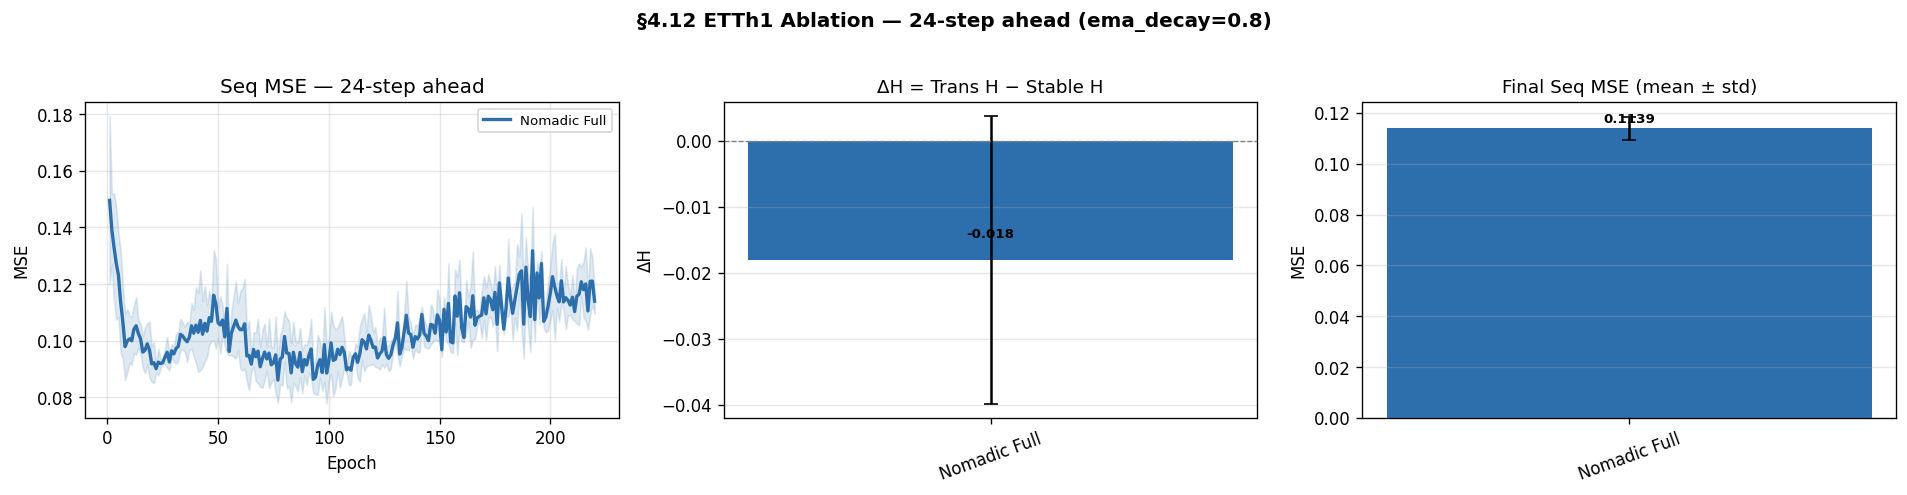

Plot saved: outputs_etth1_ablation/ablation_24step_ema0.8.png


In [41]:
# ============================================================
# STEP 11: 시각화
# ============================================================
PALETTE = {
    'Nomadic_Full': '#2C6FAC',
    'No_PolicyNet': '#E07B54',
    'No_DeltaErr':  '#5BAD6F',
    'No_Lcons':     '#9B59B6',
    'No_Ldwell':    '#E8A838',
}
LABELS = {
    'Nomadic_Full': 'Nomadic Full',
    'No_PolicyNet': 'w/o PolicyNet',
    'No_DeltaErr':  'w/o Δx_err',
    'No_Lcons':     'w/o L_cons',
    'No_Ldwell':    'w/o L_dwell',
}

ran = [v for v in RUN_VARIANTS if all_results.get(v)]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# (1) MSE 학습 곡선
ax = axes[0]
for v in ran:
    logs = [all_results[v][s]['mse_log'] for s in SEEDS if s in all_results[v]]
    if not logs: continue
    m = np.mean(logs, axis=0); s = np.std(logs, axis=0)
    ep = range(1, len(m)+1)
    ax.plot(ep, m, label=LABELS.get(v, v), color=PALETTE.get(v, 'gray'), linewidth=2)
    ax.fill_between(ep, m-s, m+s, alpha=0.15, color=PALETTE.get(v, 'gray'))
ax.set_title(f'Seq MSE — {HORIZON}-step ahead', fontsize=12)
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# (2) ΔH bar
ax = axes[1]
dh_m, dh_s, clrs, xlabels = [], [], [], []
for v in ran:
    dh_per = []
    for seed in SEEDS:
        if seed not in all_results[v]: continue
        d = all_results[v][seed]['dyn_log'][-1]
        dh_per.append(d['trans_h'] - d['stable_h'])
    if not dh_per: continue
    dh_m.append(np.nanmean(dh_per)); dh_s.append(np.nanstd(dh_per))
    clrs.append(PALETTE.get(v, 'gray')); xlabels.append(LABELS.get(v, v))
bars = ax.bar(xlabels, dh_m, color=clrs, yerr=dh_s, capsize=4, width=0.55)
ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax.set_title('ΔH = Trans H − Stable H', fontsize=11)
ax.set_ylabel('ΔH')
for bar, val in zip(bars, dh_m):
    ax.text(bar.get_x()+bar.get_width()/2., bar.get_height()+0.003,
            f'{val:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
ax.tick_params(axis='x', rotation=20); ax.grid(axis='y', alpha=0.3)

# (3) Final MSE bar
ax = axes[2]
mse_m, mse_s, clrs2, xlabels2 = [], [], [], []
for v in ran:
    vals = [all_results[v][s]['mse_log'][-1] for s in SEEDS if s in all_results[v]]
    if not vals: continue
    mse_m.append(np.nanmean(vals)); mse_s.append(np.nanstd(vals))
    clrs2.append(PALETTE.get(v, 'gray')); xlabels2.append(LABELS.get(v, v))
bars2 = ax.bar(xlabels2, mse_m, color=clrs2, yerr=mse_s, capsize=4, width=0.55)
ax.set_title('Final Seq MSE (mean ± std)', fontsize=11)
ax.set_ylabel('MSE')
for bar, val in zip(bars2, mse_m):
    ax.text(bar.get_x()+bar.get_width()/2., bar.get_height()+0.001,
            f'{val:.4f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
ax.tick_params(axis='x', rotation=20); ax.grid(axis='y', alpha=0.3)

plt.suptitle(f'§4.12 ETTh1 Ablation — {HORIZON}-step ahead (ema_decay={Config().ema_decay})',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
fname = f'{Config().save_dir}/ablation_{HORIZON}step_ema{Config().ema_decay}.png'
plt.savefig(fname, dpi=150, bbox_inches='tight')
plt.show()
print(f'Plot saved: {fname}')

In [42]:
# ============================================================
# STEP 12: PAPER.md 반영용 마크다운 출력
# ============================================================
print(f'\n§4.12 ETTh1 Ablation ({HORIZON}-step, ema_decay={Config().ema_decay})')
print('| Variant | Seq MSE | MSE std | ΔH | ΔH std | Stable H | Trans H | Switch Lat |')
print('|---|---|---|---|---|---|---|---|')
for variant in RUN_VARIANTS:
    if variant not in all_results or not all_results[variant]: continue
    mse_v, sh_v, th_v, dh_v, lat_v = [], [], [], [], []
    for seed in SEEDS:
        if seed not in all_results[variant]: continue
        r = all_results[variant][seed]
        mse_v.append(r['mse_log'][-1])
        d = r['dyn_log'][-1]
        sh, th = d['stable_h'], d['trans_h']
        sh_v.append(sh); th_v.append(th)
        dh_v.append(th - sh if not (math.isnan(th) or math.isnan(sh)) else float('nan'))
        lat_v.append(d['switch_lat'])
    lat_str = f"{np.nanmean(lat_v):.3f}" if not math.isnan(np.nanmean(lat_v)) else '—'
    print(f'| {LABELS.get(variant, variant)} | '
          f'{np.nanmean(mse_v):.4f} | {np.nanstd(mse_v):.4f} | '
          f'{np.nanmean(dh_v):.4f} | {np.nanstd(dh_v):.4f} | '
          f'{np.nanmean(sh_v):.4f} | {np.nanmean(th_v):.4f} | {lat_str} |')


§4.12 ETTh1 Ablation (24-step, ema_decay=0.8)
| Variant | Seq MSE | MSE std | ΔH | ΔH std | Stable H | Trans H | Switch Lat |
|---|---|---|---|---|---|---|---|
| Nomadic Full | 0.1139 | 0.0044 | -0.0180 | 0.0217 | 1.0770 | 1.0590 | 4.146 |
